# Reward Machine 复现

## 1. 科学问题

RM 状态 $u$ 能否把依赖任务历史的奖励过程表示为 Product MDP $(s,u)$，并使同一环境位置 $s$ 在不同 $u$ 下产生不同最优策略？


## 2. 数学定义

- $U$：RM 状态集；$u_0$ 初始；终止集吸收。
- $\delta_u(u, L(s'))$：任务进度u的更新
- $\delta_r$：进入终止给 1，其余 0。
- $L(s')$：位置命题名称集合。
- Product MDP 状态 $(s,u)$，$(s,u,a)$ 决定 $s'$、$u'$ 与奖励。

In [1]:
import sys
from pathlib import Path
ROOT = Path('..')
sys.path.insert(0, str(ROOT.resolve()))
from src.config import load_officeworld_config, load_reward_machine_config
from src.envs.officeworld import OfficeWorld
from src.task_fsm.reward_machine import RewardMachine

env = OfficeWorld(load_officeworld_config())
rm = RewardMachine(load_reward_machine_config('coffee_office'))
print('actions:', env.actions)
print('positions:', len(env.positions))
print('RM:', rm.initial_state, '->', rm.terminal_states)
for t in rm.transitions:
    print(t)

actions: ('U', 'D', 'L', 'R')
positions: 21
RM: u0 -> {'u2'}
{'from': 'u0', 'match': ['coffee'], 'to': 'u1', 'reward': 0}
{'from': 'u1', 'match': ['office'], 'to': 'u2', 'reward': 1}


地图示意
 
```text
       col 0 1 2 3 4
row 0     A . B . C
row 1     . # . . .
row 2     . . S # .
row 3     . # . # .
row 4     D . f . O
```

## 3. 完整回合（任务一 coffee→office）

从 $((2,2), u_0)$ 执行 $D,D,R,R$，逐步输出 $s,u,a,s',L,u',r,\text{terminal}$。

In [2]:
from src.algorithms.product_mdp import transition
s, u = (2,2), 'u0'
for i, a in enumerate(['D','D','R','R'], 1):
    s_next, u_next, r, term = transition(env, rm, s, u, a)
    L = env.label(s_next)
    print(i, s, u, a, '->', s_next, L, u_next, r, term)
    s, u = s_next, u_next

1 (2, 2) u0 D -> (3, 2) set() u0 0.0 False
2 (3, 2) u0 D -> (4, 2) {'coffee'} u1 0.0 False
3 (4, 2) u1 R -> (4, 3) set() u1 0.0 False
4 (4, 3) u1 R -> (4, 4) {'office'} u2 1.0 True


## 4. Value Iteration

在 $(s,u)$ 上表格 VI，同步更新，终止价值 0，残差 $< 10^{-8}$。

In [3]:
from src.algorithms.value_iteration import value_iteration
values, action_values, policy, iters, resid, conv = value_iteration(env, rm)
print('iterations:', iters, 'residual:', round(resid, 12), 'converged:', conv)
print('V[(2,2),u0] =', round(values[((2,2),'u0')], 6), ' expect 0.99^3 =', round(0.99**3, 6))
print('V[(4,3),u0] =', round(values[((4,3),'u0')], 6), ' expect 0.99^2 =', round(0.99**2, 6))
print('V[(4,3),u1] =', round(values[((4,3),'u1')], 6), ' expect 1.0')

iterations: 9 residual: 0.0 converged: True
V[(2,2),u0] = 0.970299  expect 0.99^3 = 0.970299
V[(4,3),u0] = 0.9801  expect 0.99^2 = 0.9801
V[(4,3),u1] = 1.0  expect 1.0


## 5. 主要结果：策略对比

同一位置 $(4,3)$：最优动作不同，价值也不同。
这验证 RM 把任务历史编码进 $(s,u)$ 后，能产生**位置-状态依赖**的策略差异。

图见 `figures/policy_comparison.svg`（由 `experiments/make_policy_figure.py` 生成）。

saved: E:\skill\Training\minecraft-mdp\figures\policy_comparison.svg
saved: E:\skill\Training\minecraft-mdp\figures\policy_comparison.png


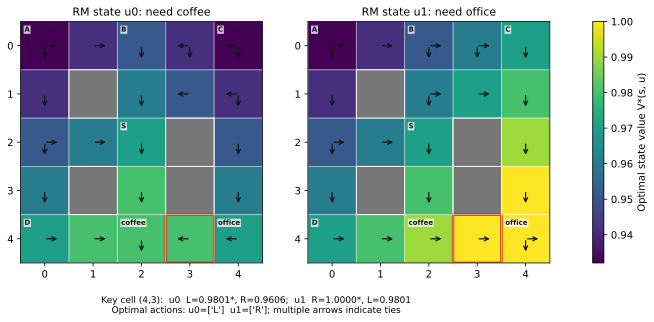

In [4]:
from experiments.make_policy_figure import make_policy_figure
from IPython.display import SVG

svg_path, _ = make_policy_figure()
SVG(filename=str(svg_path))

## 6. Q-learning：一条经验只更新实际状态

先用一条可算的非终止经验检查更新公式：

$$
Q(s,u,a) \leftarrow Q(s,u,a) + \alpha\left[r + \gamma\max_{a'}Q(s',u',a') - Q(s,u,a)\right].
$$

从 `(3,2)`、`u0` 向下进入 coffee：`s_next=(4,2)`、`u_next=u1`、`reward=0`。令当前 Q 值为 0.1，下一状态最大 Q 值为 0.4；当 $\alpha=0.1,\gamma=0.99$ 时，更新结果应为 0.1296。下面直接调用 `src.algorithms.q_learning`。

In [5]:
from src.algorithms.q_learning import init_Q, q_update

alpha = 0.1

gamma = 0.99
s, u, action = (3, 2), 'u0', 'D'
s_next, u_next, reward, terminal = transition(env, rm, s, u, action)

Q_ql = init_Q(env, rm)
Q_ql[(s, u)][action] = 0.1
Q_ql[(s_next, u_next)] = {'U': 0.1, 'D': 0.2, 'L': 0.3, 'R': 0.4}

before = Q_ql[(s, u)][action]
target = reward + gamma * max(Q_ql[(s_next, u_next)].values())
q_update(
    Q_ql, s, u, action, reward, s_next, u_next,
    terminal, alpha, gamma,
)
after = Q_ql[(s, u)][action]

print('experience:', (s, u, action), '->', (s_next, u_next), 'reward=', reward)
print('target:', target)
print('Q before:', before)
print('Q after: ', after, '(expected 0.1296)')

experience: ((3, 2), 'u0', 'D') -> ((4, 2), 'u1') reward= 0.0
target: 0.396
Q before: 0.1
Q after:  0.12960000000000002 (expected 0.1296)


## 7. QRM：同一条经验更新多个 RM 状态

QRM 不重复执行环境动作，复用 `(s, action, s_next, labels)`。对每个非终止假设状态 `u_prime`，分别计算下一 RM 状态、奖励和终止标记，再调用同一个 `q_update()`。


In [6]:
from src.algorithms.qrm import qrm_update

labels = env.label(s_next)
Q_qrm = init_Q(env, rm)
Q_qrm[(s_next, 'u1')] = {'U': 0.1, 'D': 0.2, 'L': 0.3, 'R': 0.4}
Q_qrm[(s, 'u0')][action] = 0.1
Q_qrm[(s, 'u1')][action] = 0.2

before = {
    task_state: Q_qrm[(s, task_state)][action]
    for task_state in sorted(rm.states)
}
qrm_update(Q_qrm, rm, s, action, s_next, labels, alpha, gamma)

after = {
    task_state: Q_qrm[(s, task_state)][action]
    for task_state in sorted(rm.states)
}
print('one real experience:', (s, action, s_next, labels))
print('RM state | before -> after')
for task_state in sorted(rm.states):
    print(f'{task_state:8s} | {before[task_state]:.4f} -> {after[task_state]:.4f}')

one real experience: ((3, 2), 'D', (4, 2), {'coffee'})
RM state | before -> after
u0       | 0.1000 -> 0.1296
u1       | 0.2000 -> 0.2196
u2       | 0.0000 -> 0.0000


## 8. 完整学习对照

两种方法都观察完整状态 $(s,u)$，并使用相同设置：

| 参数 | 值 |
| --- | --- |
| $\alpha$ | 0.1 |
| $\gamma$ | 0.99 |
| $\epsilon$ | 0.1 |
| Q 初值 | 0.0 |
| 随机种子 | 0–9，共 10 次独立训练 |
| 每个评估点 | 20 个贪心回合 |

横轴统一使用真实环境交互次数。

  coffee_office  Q-learning  final=1.000
  coffee_office  QRM         final=1.000
  -> E:\skill\Training\minecraft-mdp\figures\learning_curves_coffee_office.svg
  visit_abcd     Q-learning  final=1.000
  visit_abcd     QRM         final=1.000
  -> E:\skill\Training\minecraft-mdp\figures\learning_curves_visit_abcd.svg

Raw data: E:\skill\Training\minecraft-mdp\experiments\results\learning_curves.csv (800 rows)


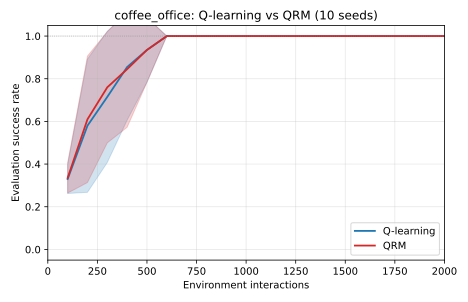

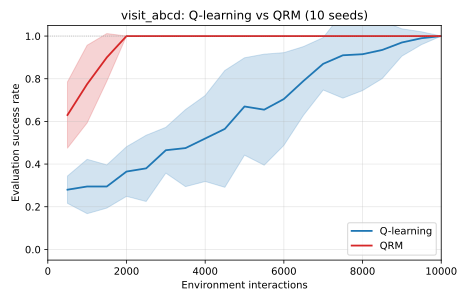

In [7]:
from experiments import make_learning_curves
from IPython.display import SVG, display

make_learning_curves.main()
display(SVG(filename=str(ROOT / 'figures/learning_curves_coffee_office.svg')))
display(SVG(filename=str(ROOT / 'figures/learning_curves_visit_abcd.svg')))

## 9. 学习结果

逐种子原始结果保存在 `experiments/results/learning_curves.csv`，共 800 行。图中实线是 10 个种子的平均成功率，阴影是跨种子标准差。

| 任务 | 方法 | 首次平均成功率 ≥ 0.9 | 最终成功率 | 最终平均回报 | 最终平均步数 |
| --- | --- | ---: | ---: | ---: | ---: |
| coffee → office | Q-learning | 500 | 1.0 | 0.970299 | 4.0 |
| coffee → office | QRM | 500 | 1.0 | 0.970299 | 4.0 |
| A → B → C → D | Q-learning | 7,500 | 1.0 | 0.858347 | 16.2 |
| A → B → C → D | QRM | 1,500 | 1.0 | 0.849891 | 17.2 |

任务一中两种方法没有可见差异。任务二中，QRM 更早学会稳定完成任务，说明反事实更新提高了按环境交互数衡量的样本效率；但在固定预算结束时，Q-learning 的平均回报和完成步数更接近 VI 最优策略。成功率达到 1 不表示路线已经最短。

VI 最优回报分别为 $0.99^3=0.970299$ 和 $0.99^{15}\approx0.860058$。任务二最终回报差距为：Q-learning 约 0.001712，QRM 约 0.010167。

QRM 每次环境交互会执行更多 Q 更新，因此样本效率优势不等于计算耗时优势。


